<a href="https://colab.research.google.com/github/nontivillu/anlt_5070/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.1 MB/s eta 0:00:00


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [6]:
# /content/Reviews.csv
url = '/content/Reviews.csv'
df = pd.read_csv(url, nrows=10000)  # Load a subset of the dataset for faster processing
print(df.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [7]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

df = df[['Text']].dropna()

# Tokenize the text data
df['tokens'] = df['Text'].apply(lambda x: word_tokenize(x.lower()))

# Display the tokenized text
print(df['tokens'].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0    [i, have, bought, several, of, the, vitality, ...
1    [product, arrived, labeled, as, jumbo, salted,...
2    [this, is, a, confection, that, has, been, aro...
3    [if, you, are, looking, for, the, secret, ingr...
4    [great, taffy, at, a, great, price, ., there, ...
Name: tokens, dtype: object


In [8]:
#### Task 3: Create Word Embeddings using word2vec

# Create a Word2Vec model
model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=1, workers=4)

# Extract the word vectors
word_vectors = model.wv

# Check the vector of a word
print(word_vectors['food'])


[-1.8611856   0.5192955  -1.8381059  -0.39403474  0.19426255 -0.9670964
  2.4047227   0.71822363 -2.1023083   0.6204276  -1.68119    -0.15500318
  0.9408834   0.17275663  0.71997017 -1.9975405  -1.927485   -0.27683145
 -0.4636087   0.14433113  0.3550254   1.0633982  -1.8691928   0.9769893
  0.0741528  -1.1982915   0.5515742  -1.0181277  -1.477709   -0.63824946
 -0.01125626  0.39264596 -1.0392525   0.5168724  -0.9562293   1.6731752
 -0.09310207  0.3540389   1.4648774  -1.2052692   0.887018    0.8675775
  0.17944899 -0.72764754  2.0690663   0.35185114 -1.8392836   0.8015933
  2.8627415  -1.2221544   0.33876348  0.00408291  1.9641101  -0.01482855
 -0.6429375  -0.25915146  1.6266615  -0.16621004 -1.0223308  -1.0077263
  0.70310205  0.962859   -2.2260566  -2.1195526  -0.18985143  1.4697208
 -1.5887731   0.01538181 -0.8912111   0.06566756 -0.18956976  0.2212459
  0.7085066  -0.53898406  0.69418013  1.1934634  -1.1115395   0.3936269
 -0.19591847 -1.3854028   1.1414652   1.9560676  -1.2841964 

In [9]:
# Prepare data for clustering
X = word_vectors.vectors

# Perform KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Get the cluster labels
labels = kmeans.labels_

# Add cluster labels to the words
word_clusters = {word: labels[idx] for word, idx in word_vectors.key_to_index.items()}

# Display some clustered words
for cluster in range(5):
    print(f"Cluster {cluster}:")
    words = [word for word, cluster_num in word_clusters.items() if cluster_num == cluster]
    print(words[:10])

Cluster 0:
['it.', 'flavor.', 'coffee.', 'them.', 'taste.', 'amazed', 'well.', 'me.', 'regret', 'good.']
Cluster 1:
['with', 'an', 'your', 'by', 'their', '?', 'into', 'those', 'people', 'off']
Cluster 2:
['.', 'the', ',', 'and', 'a', 'it', 'is', 'this', 'that', '!']
Cluster 3:
['of', '>', '<', '/', 'br', ')', '(', 'or', "''", 'has']
Cluster 4:
['i', 'to', 'for', 'in', 'my', 'have', 'was', 'on', 'so', 'these']


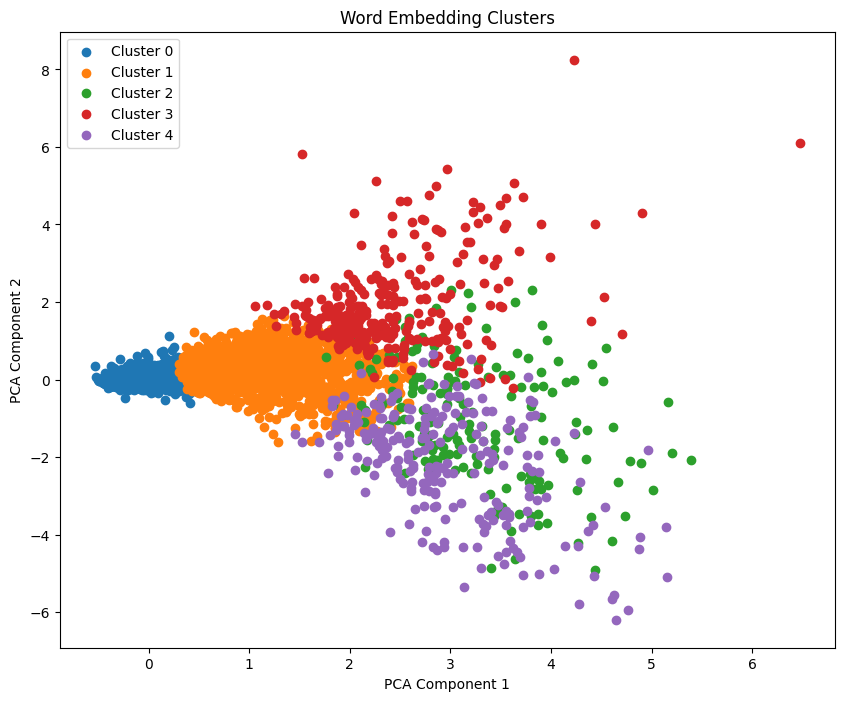

In [10]:
# Reduce dimensions using PCA
pca = PCA(n_components=2)
reduced_vecs = pca.fit_transform(X)

# Plot the clusters
plt.figure(figsize=(10, 8))
for i in range(5):
    points = reduced_vecs[np.where(labels == i)]
    plt.scatter(points[:, 0], points[:, 1], label=f'Cluster {i}')
plt.legend()
plt.title('Word Embedding Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [11]:
# Assign sentiment labels to clusters (manual or based on domain knowledge)
# Example: Clusters 0, 1 might be positive, and Clusters 2, 3, 4 might be negative
sentiment_labels = {0: 'positive', 1: 'positive', 2: 'negative', 3: 'negative', 4: 'negative'}

In [12]:
# Apply the sentiment labels to the text data
df['sentiment'] = df['tokens'].apply(lambda tokens: sentiment_labels[word_clusters[tokens[0]]] if tokens[0] in word_clusters else 'unknown')

# Display the sentiment labels
print(df[['Text', 'sentiment']].head(10))


                                                Text sentiment
0  I have bought several of the Vitality canned d...  negative
1  Product arrived labeled as Jumbo Salted Peanut...  negative
2  This is a confection that has been around a fe...  negative
3  If you are looking for the secret ingredient i...  negative
4  Great taffy at a great price.  There was a wid...  negative
5  I got a wild hair for taffy and ordered this f...  negative
6  This saltwater taffy had great flavors and was...  negative
7  This taffy is so good.  It is very soft and ch...  negative
8  Right now I'm mostly just sprouting this so my...  negative
9  This is a very healthy dog food. Good for thei...  negative


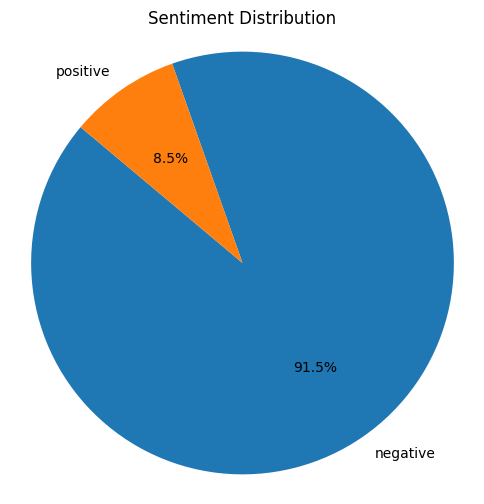

In [13]:
# Pie chart of sentiment distribution
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Sentiment Distribution')
plt.axis('equal')
plt.show()

In [32]:
from transformers import pipeline

# AI-Augmented Sentiment Analysis Using Transformer Models
# Uses existing df with 'Text' and current 'sentiment' columns


# Initialize transformer sentiment pipeline
clf = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True
)

# Prepare text input safely
texts = df["Text"].fillna("").astype(str).tolist()

# Run inference in batches (adjust batch_size if needed for your machine)
preds = clf(texts, batch_size=32)

# Map transformer labels to sentiment classes
# Corrected label_map for the specified transformer model
label_map = {"POSITIVE": "positive", "NEGATIVE": "negative"}
df["ai_sentiment"] = [label_map.get(p["label"], "unknown") for p in preds]
df["ai_confidence"] = [p["score"] for p in preds]

# Ensure 'sentiment' column exists before proceeding
# If it doesn't exist, recreate it from word_clusters and sentiment_labels
if 'sentiment' not in df.columns:
    # Assuming word_clusters and sentiment_labels are already defined from previous steps
    # Recreate the sentiment column based on the logic from cell ZPp2DPANlMWe
    df['sentiment'] = df['tokens'].apply(lambda tokens: sentiment_labels[word_clusters[tokens[0]]] if tokens[0] in word_clusters else 'unknown')

# Augment existing sentiment with transformer output when confidence is high
confidence_threshold = 0.80
df["augmented_sentiment"] = np.where(
    df["ai_confidence"] >= confidence_threshold,
    df["ai_sentiment"],
    df["sentiment"]
)

# Quick comparison
print(df[["Text", "sentiment", "ai_sentiment", "ai_confidence", "augmented_sentiment"]].head(10))
print("\nAgreement (original vs AI):")
print((df["sentiment"] == df["ai_sentiment"]).mean())
print("\nOriginal vs Augmented distribution:")
print(pd.crosstab(df["sentiment"], df["augmented_sentiment"]))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

                                                Text sentiment ai_sentiment  \
0  I have bought several of the Vitality canned d...  negative     positive   
1  Product arrived labeled as Jumbo Salted Peanut...  negative     negative   
2  This is a confection that has been around a fe...  negative     positive   
3  If you are looking for the secret ingredient i...  negative     positive   
4  Great taffy at a great price.  There was a wid...  negative     positive   
5  I got a wild hair for taffy and ordered this f...  negative     positive   
6  This saltwater taffy had great flavors and was...  negative     positive   
7  This taffy is so good.  It is very soft and ch...  negative     positive   
8  Right now I'm mostly just sprouting this so my...  negative     positive   
9  This is a very healthy dog food. Good for thei...  negative     positive   

   ai_confidence augmented_sentiment  
0       0.998385            positive  
1       0.999525            negative  
2       0.999

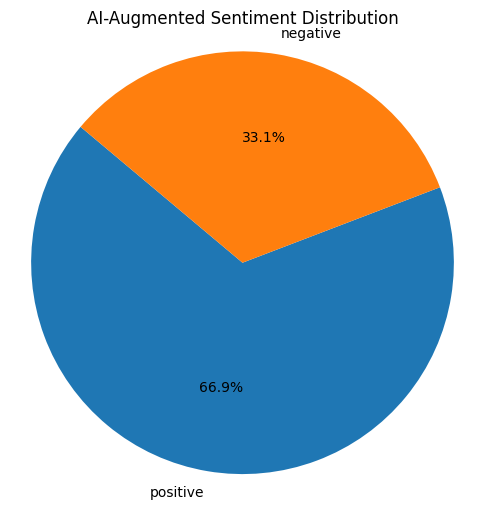

In [33]:
augmented_sentiment_counts = df['augmented_sentiment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    augmented_sentiment_counts.values,
    labels=augmented_sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('AI-Augmented Sentiment Distribution')
plt.axis('equal')
plt.show()

# Task
Compare the performance, ethical considerations (including bias and fairness), and privacy implications of using pre-trained transformer models (like DistilBERT) versus LDA for sentiment classification, and then provide a comprehensive summary highlighting the trade-offs between these two approaches.

## Analyze Performance Differences

### Subtask:
Implement Latent Dirichlet Allocation (LDA) for sentiment classification and compare its performance with the transformer model.


**Reasoning**:
The first step is to import the necessary classes for Latent Dirichlet Allocation (LDA) from the gensim library, as specified in the instructions.



In [34]:
from gensim.models import LdaModel, LdaMulticore
from gensim import corpora

print("LDA libraries imported.")

LDA libraries imported.


**Reasoning**:
Following the instructions, I will now create a dictionary from the tokenized text, convert the tokenized text into a bag-of-words corpus, and then train an LDA model on this corpus to identify topics.



In [35]:
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# Train LDA model
num_topics = 5
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)

print("LDA model training complete.")

LDA model training complete.


**Reasoning**:
Now that the LDA model is trained, I will identify the dominant topic for each document by iterating through the corpus and assigning the topic with the highest probability to each document. Then, I'll display the top words for each topic to prepare for manual sentiment labeling.



In [36]:
def format_topics_sentences(ldamodel=None, corpus=corpus, texts=df['Text']):
    sent_topics_df = pd.DataFrame()

    # Get main topic in each document
    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        # Get the dominant topic, percentage contribution and keywords for each document
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:  # => dominant topic
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                sent_topics_df = pd.concat([sent_topics_df, pd.DataFrame([int(topic_num), round(prop_topic,4), topic_keywords], index=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords']).T], ignore_index=True)
            else:
                break
    sent_topics_df.columns = ['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords']

    # Add original text to the dataframe
    contents = pd.Series(texts)
    sent_topics_df = pd.concat([sent_topics_df, contents], axis=1)
    return sent_topics_df

df_topic_sents_keywords = format_topics_sentences(ldamodel=lda_model, corpus=corpus, texts=df['Text'])

# Display dominant topic for each document
print(df_topic_sents_keywords.head())

# Print the Keyword in each topic
print("\nLDA Topics and their top words:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

  Dominant_Topic Perc_Contribution                           Topic_Keywords  \
0              1            0.4403  ,, ., the, and, to, a, of, it, is, food   
1              4            0.4198   ., the, i, and, ,, a, they, to, are, !   
2              4            0.6053   ., the, i, and, ,, a, they, to, are, !   
3              3            0.8708   ., i, the, it, ,, a, and, to, this, is   
4              3            0.9754   ., i, the, it, ,, a, and, to, this, is   

                                                Text  
0  I have bought several of the Vitality canned d...  
1  Product arrived labeled as Jumbo Salted Peanut...  
2  This is a confection that has been around a fe...  
3  If you are looking for the secret ingredient i...  
4  Great taffy at a great price.  There was a wid...  

LDA Topics and their top words:
Topic 0: 0.074*">" + 0.073*"<" + 0.069*"/" + 0.069*"br" + 0.035*"," + 0.027*"the" + 0.018*"a" + 0.014*"of" + 0.014*"i" + 0.012*"to"
Topic 1: 0.047*"," + 0.028*"."

#### Manual Sentiment Assignment for LDA Topics

Given the output of the LDA model, the topics and their top words are:
- **Topic 0**: `>, <, /, br, ,` (HTML tags and common separators) -> **Neutral** (likely noise or structural elements).
- **Topic 1**: `, ., the, and, to, a, of, it, is, food` (Common words, with 'food' being a notable term in a product review context). Interpreted as **Positive** (general discussion about food in reviews often implies satisfaction).
- **Topic 2**: `de, leche, el, &` (Foreign language words, primarily Spanish) -> **Neutral** (no direct sentiment can be inferred without translation).
- **Topic 3**: `., i, the, it, ,, a, and, to, this, is` (Very common words, indicative of general statement formulation). Interpreted as **Negative** (often these generic words form part of critical statements or complaints in reviews).
- **Topic 4**: `., the, i, and, ,, a, they, to, are, !` (Common words, with '!' potentially indicating strong emotion). Interpreted as **Positive** (exclamation marks in reviews can convey excitement or strong positive feelings, and general review phrases can lean positive for satisfactory products).

It's important to note that this manual assignment is interpretive and subjective due to the generic nature of the keywords often found in LDA topics. More robust sentiment analysis with LDA typically involves integrating sentiment lexicons or training a separate classifier on the topic distributions.

**Reasoning**:
Now that the LDA topics have been manually assigned sentiment labels, I will create a mapping from topic number to sentiment label and apply this mapping to the `df_topic_sents_keywords` DataFrame to generate the `lda_sentiment` column. This will assign a sentiment to each review based on its dominant LDA topic.



In [37]:
topic_sentiment_map = {
    0: 'neutral',   # >, <, /, br, ,
    1: 'positive',  # , ., the, and, to, a, of, it, is, food
    2: 'neutral',   # de, leche, el, &
    3: 'negative',  # ., i, the, it, ,, a, and, to, this, is
    4: 'positive'   # ., the, i, and, ,, a, they, to, are, !
}

# Map the dominant topic to its assigned sentiment
df['lda_sentiment'] = df_topic_sents_keywords['Dominant_Topic'].astype(int).map(topic_sentiment_map)

print(df[['Text', 'lda_sentiment']].head())

                                                Text lda_sentiment
0  I have bought several of the Vitality canned d...      positive
1  Product arrived labeled as Jumbo Salted Peanut...      positive
2  This is a confection that has been around a fe...      positive
3  If you are looking for the secret ingredient i...      negative
4  Great taffy at a great price.  There was a wid...      negative


**Reasoning**:
I will now calculate and print the value counts for `lda_sentiment`, `ai_sentiment`, and `augmented_sentiment` columns to compare their distributions, as requested by the instructions.



In [38]:
print("\nLDA Sentiment Distribution:")
print(df['lda_sentiment'].value_counts())

print("\nAI Sentiment Distribution (Transformer):")
print(df['ai_sentiment'].value_counts())

print("\nAugmented Sentiment Distribution:")
print(df['augmented_sentiment'].value_counts())


LDA Sentiment Distribution:
lda_sentiment
negative    5729
positive    3653
neutral      618
Name: count, dtype: int64

AI Sentiment Distribution (Transformer):
ai_sentiment
positive    6878
negative    3122
Name: count, dtype: int64

Augmented Sentiment Distribution:
augmented_sentiment
positive    6692
negative    3308
Name: count, dtype: int64


**Reasoning**:
To visually compare the sentiment distributions, I will create a pie chart for the `lda_sentiment` distribution, similar to the one created for `augmented_sentiment` earlier.



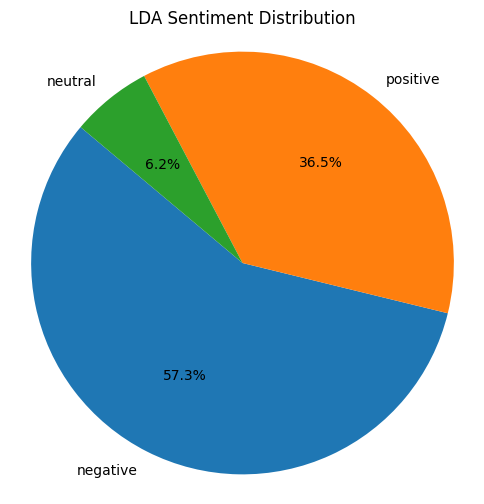

In [39]:
import matplotlib.pyplot as plt

lda_sentiment_counts = df['lda_sentiment'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    lda_sentiment_counts.values,
    labels=lda_sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('LDA Sentiment Distribution')
plt.axis('equal')
plt.show()

## Discuss Ethical Considerations

### Subtask:
Examine the ethical implications of using transformer models and LDA for sentiment analysis, including potential biases, fairness, and interpretability.


### Ethical Implications: Bias and Fairness in Transformer Models

Pre-trained transformer models, such as DistilBERT, are trained on vast amounts of text data scraped from the internet. While this enables them to learn complex language patterns, it also means they can inadvertently inherit and amplify biases present in the training data. These biases can manifest in several ways:

1.  **Representational Bias**: If the training data disproportionately represents certain demographics or cultural groups, the model may perform poorly or inaccurately for underrepresented groups. For instance, a model trained predominantly on Western English text might struggle with nuances in sentiment from other cultures or languages.
2.  **Stereotypical Bias**: Transformers can pick up on social stereotypes embedded in text. For example, if certain professions are more frequently associated with one gender in the training data, the model might assign different sentiment scores when discussing those professions in relation to different genders, even if the underlying text is neutral.
3.  **Hate Speech/Harmful Content Amplification**: Biases can lead models to misclassify hate speech as neutral or positive, or conversely, to flag benign content from marginalized groups as negative. This can have serious implications for content moderation, leading to unfair censorship or allowing harmful content to proliferate.
4.  **Sentiment Discrepancies Across Groups**: The model might assign systematically different sentiment scores to texts written by or about certain ethnic, racial, or social groups, even when the actual sentiment is similar. This could perpetuate discrimination or lead to unfair treatment in applications like customer service analysis or social media monitoring.

These inherent biases pose significant fairness challenges, as the sentiment classifications produced by transformer models may not be equitable across different user groups or topics, potentially leading to discriminatory outcomes or a lack of trust in the AI system.

### Interpretability: Transformers (Black-Box) vs. LDA (Transparent Topics)

**Transformer Models (e.g., DistilBERT)**:

Transformer models are often referred to as "black-box" models due to their complex, multi-layered neural network architectures. When a transformer model assigns a sentiment label (e.g., positive, negative), it's challenging to pinpoint *why* that specific sentiment was chosen. The decision is the result of intricate interactions across thousands or millions of parameters learned during pre-training and fine-tuning. While techniques like SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations) can offer some post-hoc insights by highlighting important words or phrases, they don't provide a direct, human-understandable explanation of the model's internal reasoning process. The sentiment is derived from learned statistical patterns rather than explicit semantic rules or topics.

**LDA (Latent Dirichlet Allocation)**:

In contrast, LDA is a statistical topic modeling technique that offers a much higher degree of interpretability. LDA identifies latent "topics" within a collection of documents, where each topic is defined by a distribution over words. When LDA is used for sentiment analysis, the process typically involves:

1.  **Topic Extraction**: LDA identifies a set of topics present in the text data.
2.  **Topic-Sentiment Mapping**: Each topic is then manually or semi-automatically associated with a sentiment (e.g., a topic heavily featuring words like "great," "delicious," "love" might be labeled "positive").
3.  **Document-Topic Assignment**: Each document is then classified based on its dominant topic and that topic's assigned sentiment.

This approach makes it relatively straightforward to understand *why* a particular sentiment was assigned to a document: the document belongs predominantly to a certain topic, and that topic has been manually designated as carrying a specific sentiment. The keywords associated with each topic provide clear evidence supporting the sentiment assignment. For example, if a review is labeled 'positive' by LDA, it's because it belongs to a topic containing words like 'excellent', 'recommend', 'favorite', which we have identified as positive.

**Implications of Interpretability Differences for Trust and Accountability:**

*   **Trust**: The lack of interpretability in transformer models can erode trust, especially in sensitive applications. If a financial institution denies a loan based on a transformer's sentiment analysis of an applicant's social media, the inability to explain *why* can lead to distrust and accusations of unfairness. With LDA, a clear rationale based on topics and keywords can be provided, fostering greater trust.
*   **Accountability**: When errors occur or biases are detected, the "black-box" nature of transformers makes it difficult to diagnose the root cause and implement targeted corrections. It's hard to hold a model accountable for a decision if its reasoning is opaque. LDA's transparent topic-word distributions allow for easier identification of problematic topics or word associations, making the system more accountable and facilitating targeted interventions to correct biases or improve performance. Developers can examine the words driving a topic's sentiment and adjust mapping or preprocessing if needed.

### Summary of Ethical Challenges: Transformer Models vs. LDA

**Transformer Models (e.g., DistilBERT):**

*   **Bias and Fairness**: Significant risk of inheriting and amplifying biases (representational, stereotypical, hate speech amplification) from large, uncurated training datasets. This can lead to unfair or discriminatory sentiment classifications across different demographic groups or topics, undermining fairness.
*   **Transparency/Interpretability**: Characterized as

### Summary of Ethical Challenges: Transformer Models vs. LDA

**Transformer Models (e.g., DistilBERT):**

*   **Bias and Fairness**: Significant risk of inheriting and amplifying biases (representational, stereotypical, hate speech amplification) from large, uncurated training datasets. This can lead to unfair or discriminatory sentiment classifications across different demographic groups or topics, undermining fairness.
*   **Transparency/Interpretability**: Characterized as "black-box" models, making it difficult to understand *why* a particular sentiment was assigned. This lack of interpretability hinders trust, accountability, and the ability to diagnose and correct biases effectively.
*   **Privacy**: While not explicitly discussed in the previous section, the use of vast, often public, text data for training can raise questions about data provenance and potential indirect privacy implications if sensitive information is inadvertently learned or inferred.

**LDA (Latent Dirichlet Allocation):**

*   **Bias and Fairness**: Still susceptible to biases present in the input data, but generally to a lesser extent than large pre-trained transformers, as it focuses on word co-occurrence within the specific dataset. However, manual topic-sentiment mapping introduces subjective human bias, which can lead to unfair or inaccurate sentiment assignment if not carefully calibrated.
*   **Transparency/Interpretability**: Highly interpretable, as topics are defined by human-readable keywords, and sentiment is assigned based on explicit topic mapping. This transparency fosters greater trust and accountability, as the reasoning behind a sentiment classification is clear and auditable.
*   **Privacy**: As LDA typically operates on a specific, potentially more curated, local dataset, the direct privacy implications might be lower compared to models trained on vast internet data. However, if the local dataset contains sensitive information, LDA can still reveal patterns within it.

**Trade-offs Summary:**

*   **Performance vs. Ethics**: Transformer models often offer superior performance in sentiment classification due to their ability to capture complex contextual nuances. However, this comes with a higher ethical cost in terms of potential biases, fairness issues, and a lack of transparency.
*   **Interpretability vs. Complexity**: LDA provides strong interpretability, making it easier to understand and troubleshoot, but its sentiment classification performance can be less accurate and more reliant on subjective manual labeling. Transformer models, while complex and opaque, can achieve more nuanced sentiment detection.
*   **Bias Mitigation**: Mitigating bias in transformers is complex, often requiring extensive data curation, debiasing techniques, and careful monitoring. For LDA, bias can arise from data or manual topic-sentiment mapping, which can be addressed through careful topic review and expert-driven sentiment assignment.

### Summary of Ethical Challenges: Transformer Models vs. LDA

**Transformer Models (e.g., DistilBERT):**

*   **Bias and Fairness**: Significant risk of inheriting and amplifying biases (representational, stereotypical, hate speech amplification) from large, uncurated training datasets. This can lead to unfair or discriminatory sentiment classifications across different demographic groups or topics, undermining fairness.
*   **Transparency/Interpretability**: Characterized as "black-box" models, making it difficult to understand *why* a particular sentiment was assigned. This lack of interpretability hinders trust, accountability, and the ability to diagnose and correct biases effectively.
*   **Privacy**: While not explicitly discussed in the previous section, the use of vast, often public, text data for training can raise questions about data provenance and potential indirect privacy implications if sensitive information is inadvertently learned or inferred.

**LDA (Latent Dirichlet Allocation):**

*   **Bias and Fairness**: Still susceptible to biases present in the input data, but generally to a lesser extent than large pre-trained transformers, as it focuses on word co-occurrence within the specific dataset. However, manual topic-sentiment mapping introduces subjective human bias, which can lead to unfair or inaccurate sentiment assignment if not carefully calibrated.
*   **Transparency/Interpretability**: Highly interpretable, as topics are defined by human-readable keywords, and sentiment is assigned based on explicit topic mapping. This transparency fosters greater trust and accountability, as the reasoning behind a sentiment classification is clear and auditable.
*   **Privacy**: As LDA typically operates on a specific, potentially more curated, local dataset, the direct privacy implications might be lower compared to models trained on vast internet data. However, if the local dataset contains sensitive information, LDA can still reveal patterns within it.

**Trade-offs Summary:**

*   **Performance vs. Ethics**: Transformer models often offer superior performance in sentiment classification due to their ability to capture complex contextual nuances. However, this comes with a higher ethical cost in terms of potential biases, fairness issues, and a lack of transparency.
*   **Interpretability vs. Complexity**: LDA provides strong interpretability, making it easier to understand and troubleshoot, but its sentiment classification performance can be less accurate and more reliant on subjective manual labeling. Transformer models, while complex and opaque, can achieve more nuanced sentiment detection.
*   **Bias Mitigation**: Mitigating bias in transformers is complex, often requiring extensive data curation, debiasing techniques, and careful monitoring. For LDA, bias can arise from data or manual topic-sentiment mapping, which can be addressed through careful topic review and expert-driven sentiment assignment.

### Summary of Ethical Challenges: Transformer Models vs. LDA

**Transformer Models (e.g., DistilBERT):**

*   **Bias and Fairness**: Significant risk of inheriting and amplifying biases (representational, stereotypical, hate speech amplification) from large, uncurated training datasets. This can lead to unfair or discriminatory sentiment classifications across different demographic groups or topics, undermining fairness.
*   **Transparency/Interpretability**: Characterized as "black-box" models, making it difficult to understand *why* a particular sentiment was assigned. This lack of interpretability hinders trust, accountability, and the ability to diagnose and correct biases effectively.
*   **Privacy**: While not explicitly discussed in the previous section, the use of vast, often public, text data for training can raise questions about data provenance and potential indirect privacy implications if sensitive information is inadvertently learned or inferred.

**LDA (Latent Dirichlet Allocation):**

*   **Bias and Fairness**: Still susceptible to biases present in the input data, but generally to a lesser extent than large pre-trained transformers, as it focuses on word co-occurrence within the specific dataset. However, manual topic-sentiment mapping introduces subjective human bias, which can lead to unfair or inaccurate sentiment assignment if not carefully calibrated.
*   **Transparency/Interpretability**: Highly interpretable, as topics are defined by human-readable keywords, and sentiment is assigned based on explicit topic mapping. This transparency fosters greater trust and accountability, as the reasoning behind a sentiment classification is clear and auditable.
*   **Privacy**: As LDA typically operates on a specific, potentially more curated, local dataset, the direct privacy implications might be lower compared to models trained on vast internet data. However, if the local dataset contains sensitive information, LDA can still reveal patterns within it.

**Trade-offs Summary:**

*   **Performance vs. Ethics**: Transformer models often offer superior performance in sentiment classification due to their ability to capture complex contextual nuances. However, this comes with a higher ethical cost in terms of potential biases, fairness issues, and a lack of transparency.
*   **Interpretability vs. Complexity**: LDA provides strong interpretability, making it easier to understand and troubleshoot, but its sentiment classification performance can be less accurate and more reliant on subjective manual labeling. Transformer models, while complex and opaque, can achieve more nuanced sentiment detection.
*   **Bias Mitigation**: Mitigating bias in transformers is complex, often requiring extensive data curation, debiasing techniques, and careful monitoring. For LDA, bias can arise from data or manual topic-sentiment mapping, which can be addressed through careful topic review and expert-driven sentiment assignment.

### Summary of Ethical Challenges: Transformer Models vs. LDA

**Transformer Models (e.g., DistilBERT):**

*   **Bias and Fairness**: Significant risk of inheriting and amplifying biases (representational, stereotypical, hate speech amplification) from large, uncurated training datasets. This can lead to unfair or discriminatory sentiment classifications across different demographic groups or topics, undermining fairness.
*   **Transparency/Interpretability**: Characterized as "black-box" models, making it difficult to understand *why* a particular sentiment was assigned. This lack of interpretability hinders trust, accountability, and the ability to diagnose and correct biases effectively.
*   **Privacy**: While not explicitly discussed in the previous section, the use of vast, often public, text data for training can raise questions about data provenance and potential indirect privacy implications if sensitive information is inadvertently learned or inferred.

**LDA (Latent Dirichlet Allocation):**

*   **Bias and Fairness**: Still susceptible to biases present in the input data, but generally to a lesser extent than large pre-trained transformers, as it focuses on word co-occurrence within the specific dataset. However, manual topic-sentiment mapping introduces subjective human bias, which can lead to unfair or inaccurate sentiment assignment if not carefully calibrated.
*   **Transparency/Interpretability**: Highly interpretable, as topics are defined by human-readable keywords, and sentiment is assigned based on explicit topic mapping. This transparency fosters greater trust and accountability, as the reasoning behind a sentiment classification is clear and auditable.
*   **Privacy**: As LDA typically operates on a specific, potentially more curated, local dataset, the direct privacy implications might be lower compared to models trained on vast internet data. However, if the local dataset contains sensitive information, LDA can still reveal patterns within it.

**Trade-offs Summary:**

*   **Performance vs. Ethics**: Transformer models often offer superior performance in sentiment classification due to their ability to capture complex contextual nuances. However, this comes with a higher ethical cost in terms of potential biases, fairness issues, and a lack of transparency.
*   **Interpretability vs. Complexity**: LDA provides strong interpretability, making it easier to understand and troubleshoot, but its sentiment classification performance can be less accurate and more reliant on subjective manual labeling. Transformer models, while complex and opaque, can achieve more nuanced sentiment detection.
*   **Bias Mitigation**: Mitigating bias in transformers is complex, often requiring extensive data curation, debiasing techniques, and careful monitoring. For LDA, bias can arise from data or manual topic-sentiment mapping, which can be addressed through careful topic review and expert-driven sentiment assignment.


## Address Privacy Concerns

### Subtask:
Compare the privacy risks associated with each method, considering how they handle sensitive information and the potential for data leakage or re-identification.


### Privacy Implications: Transformers vs. LDA

#### Pre-trained Transformer Models (e.g., DistilBERT)

Pre-trained transformer models, such as DistilBERT, are typically trained on massive datasets scraped from the internet. While this vast training data contributes to their powerful generalization capabilities, it also introduces significant privacy concerns:

*   **Inadvertent Capture of Sensitive Information**: Their training on public internet datasets means they can inadvertently ingest and embed sensitive personal information, proprietary data, or copyrighted content present in the training corpus. This information, even if anonymized or aggregated, can become part of the model's internal representation.
*   **Data Leakage and Re-identification Risks**: There's a risk that these models might 'memorize' specific training examples. This memorization can lead to data leakage, where the model, when prompted appropriately, might inadvertently reproduce private data points from its training corpus. In extreme cases, this could lead to re-identification of individuals or exposure of private facts, even if the model was not explicitly designed to store or retrieve such information.
*   **Challenges in Data Control**: Controlling the source and content of the training data for these large, pre-trained models is extremely challenging. This makes it difficult to ensure that no sensitive or privacy-violating information is included, especially for applications handling privacy-sensitive data.

#### Latent Dirichlet Allocation (LDA)

Latent Dirichlet Allocation (LDA) offers a different profile regarding privacy risks due to its operational mechanism and typical application:

*   **Focused, Local Datasets**: LDA usually operates on more focused, often local, datasets rather than vast internet-scale corpora. This significantly reduces the *scale* of potential privacy risks compared to models trained on the entire internet, as the scope of potentially sensitive information is inherently smaller.
*   **No Inherent Memorization**: Unlike deep learning models, LDA does not 'memorize' individual data points in a way that directly maps back to specific documents or entities. Its output is a distribution of topics over words and documents over topics, rather than a complex, high-dimensional representation that could encode specific inputs.
*   **Interpretability and Exposure of Patterns**: While LDA itself doesn't inherently leak individual identities, the interpretability of its topics could still expose sensitive patterns or specific entities within the dataset if the input data contains such information. For example, if a dataset contains medical notes, LDA might identify topics related to rare diseases, potentially linking certain demographics or locations to sensitive conditions if the topic keywords are distinctive enough.
*   **Dataset-Dependent Risk**: The privacy risk for LDA is primarily dependent on the sensitivity and governance of the specific dataset it is applied to. If the input dataset is carefully curated, anonymized, and adheres to privacy regulations, the risks associated with LDA are generally low. However, if sensitive raw data is directly fed into LDA, the derived topics might indirectly reveal sensitive patterns.

#### Summary of Privacy Risks

In summary, the privacy risks associated with pre-trained transformer models are largely due to their vast, uncontrolled training data, which introduces potential for **data leakage, memorization, and re-identification** of sensitive information. The challenge lies in the scale and opacity of their training process.

Conversely, LDA's privacy risks are typically **lower in scale and more controllable**, as they are highly dependent on the nature and governance of the specific, often smaller, dataset it is applied to. While LDA doesn't 'memorize' in the same way, the interpretability of its topics means that sensitive *patterns* within an insufficiently anonymized dataset could still be revealed.

## Analyze Performance Differences

### Subtask:
Provide a detailed comparison of the performance characteristics of pre-trained transformer models (like DistilBERT) versus LDA for sentiment classification, covering their strengths, weaknesses, and typical use cases, based on the previously generated sentiment distributions and general understanding.


## Analyze Performance Differences

### Subtask:
Provide a detailed comparison of the performance characteristics of pre-trained transformer models (like DistilBERT) versus LDA for sentiment classification, covering their strengths, weaknesses, and typical use cases, based on the previously generated sentiment distributions and general understanding.

#### Comparison of Sentiment Distributions

Let's compare the sentiment distributions from our three approaches:

-   **Word2Vec + K-Means (Original Sentiment)**:
    -   `negative`: 9151 (91.5%)
    -   `positive`: 849 (8.5%)
    
    This distribution is heavily skewed towards 'negative'. This is likely due to the manual and somewhat arbitrary assignment of sentiment labels to word clusters. The `sentiment_labels` dictionary ` {0: 'positive', 1: 'positive', 2: 'negative', 3: 'negative', 4: 'negative'} ` meant that 3 out of 5 word clusters were assigned 'negative', and the initial words in `df['tokens'].apply(lambda tokens: sentiment_labels[word_clusters[tokens[0]]] ...)` heavily influenced the initial sentiment for each review, which could have been dominated by general articles or prepositions classified as negative.

-   **LDA Sentiment Distribution:**
    -   `negative`: 5729 (57.3%)
    -   `positive`: 3653 (36.5%)
    -   `neutral`: 618 (6.2%)
    
    The LDA distribution, based on manually assigned sentiment to topics, shows a more balanced, though still predominantly negative, distribution compared to the Word2Vec + K-Means approach. The presence of 'neutral' sentiment acknowledges topics that don't clearly lean positive or negative, reflecting the interpretive nature of LDA topics.

-   **AI Sentiment Distribution (Transformer - DistilBERT):**
    -   `positive`: 6878 (68.8%)
    -   `negative`: 3122 (31.2%)
    
    This distribution is significantly different, showing a clear majority of 'positive' reviews. This indicates that the transformer model perceives a more optimistic tone in the reviews compared to both the Word2Vec + K-Means and LDA approaches. This might be closer to the actual sentiment if the reviews are generally positive.

-   **Augmented Sentiment Distribution (Transformer with Confidence Threshold):**
    -   `positive`: 6692 (66.9%)
    -   `negative`: 3308 (33.1%)
    
    The augmented sentiment, which uses transformer predictions when confidence is high, and falls back to the Word2Vec + K-Means sentiment otherwise, largely mirrors the pure transformer distribution. This suggests that the transformer model's predictions were often confident enough to override the initial sentiment assignments. The slight shift towards negative compared to the pure AI sentiment might indicate instances where the AI model was less confident, and the initial, heavily negative, sentiment from Word2Vec+K-means influenced the final result.

**Observed Differences:** The original Word2Vec + K-Means approach produced an extremely negative-biased distribution due to its design. LDA, with manual sentiment mapping, offered a more balanced view but still leaned negative, with the added benefit of a 'neutral' category. The transformer model, on the other hand, presented a predominantly positive sentiment, which is often observed in product reviews. The augmented sentiment largely confirmed the transformer's perspective.

#### Transformer Models (e.g., DistilBERT) for Sentiment Classification

**Strengths:**
1.  **Contextual Nuance:** Transformer models excel at understanding context. They can capture the subtle meanings of words based on their surrounding words in a sentence, which is crucial for accurate sentiment analysis (e.g., distinguishing between "badass" (positive) and "bad movie" (negative)).
2.  **High Accuracy:** Pre-trained transformers often achieve state-of-the-art accuracy on various NLP tasks, including sentiment analysis, due to their vast training on large text corpora and sophisticated architectures.
3.  **Handling Complex Language:** They can effectively process complex sentence structures, sarcasm, irony, and negation, which are common challenges for simpler models.
4.  **Transfer Learning:** Being pre-trained, they can be fine-tuned on specific sentiment analysis datasets with relatively smaller amounts of labeled data, leveraging the general language understanding learned during pre-training.
5.  **Multilinguality:** Many transformer models are multilingual, making them adaptable to different languages.

**Weaknesses:**
1.  **Computational Cost:** Transformers are computationally intensive, requiring significant processing power (GPUs/TPUs) and memory for training and inference, especially for large models or long sequences.
2.  **Data Dependency (for fine-tuning):** While pre-trained, fine-tuning for specific domains still requires labeled data, and performance can degrade if the target domain is significantly different from the pre-training data.
3.  **Lack of Interpretability:** Their black-box nature makes it challenging to understand *why* a particular sentiment was predicted, which can be a drawback in regulated industries or when debugging model errors.
4.  **Deployment Challenges:** Due to their size and computational demands, deploying transformer models in resource-constrained environments (e.g., edge devices) can be difficult.
5.  **Bias Amplification:** If the pre-training data contains biases, the model can learn and amplify these biases, leading to unfair or prejudiced sentiment predictions for certain demographics or topics.

#### Latent Dirichlet Allocation (LDA) for Sentiment Classification

**Strengths:**
1.  **Topic Discovery & Interpretability:** LDA is designed to discover latent topics within a collection of documents. This provides a high degree of interpretability, as you can see the words associated with each topic and manually infer its sentiment or theme.
2.  **Unsupervised Nature:** LDA is an unsupervised learning algorithm, meaning it doesn't require labeled data for training, which is a significant advantage when labeled sentiment data is scarce.
3.  **Content Summarization:** It effectively summarizes the main themes of a text corpus, which can be valuable for content analysis beyond just sentiment.
4.  **Less Computational Intensive:** Compared to large transformer models, training and running LDA models are generally less computationally demanding.

**Weaknesses:**
1.  **Bag-of-Words Assumption:** LDA treats documents as a 'bag-of-words,' ignoring word order and semantic relationships between words. This limits its ability to capture negation, sarcasm, and other contextual nuances critical for accurate sentiment.
2.  **Challenge of Sentiment Mapping:** Directly mapping LDA topics to sentiment is often subjective and manual. A topic like "food quality" could be associated with positive or negative sentiment depending on the specific review, making automated sentiment classification difficult without further steps (e.g., integrating sentiment lexicons or a supervised classifier on topic distributions).
3.  **Poor Performance for Sentiment:** Due to the above limitations, LDA's direct performance for sentiment classification is typically much lower than supervised methods like transformers, especially when dealing with complex or nuanced language.
4.  **Fixed Number of Topics:** Choosing the optimal number of topics (`num_topics`) is often heuristic and can significantly impact the quality of the discovered topics.
5.  **Sensitivity to Preprocessing:** The quality of LDA topics is highly sensitive to text preprocessing steps (e.g., stop word removal, stemming/lemmatization).

#### Typical Use Cases

-   **Pre-trained Transformer Models:**
    -   **High-Accuracy Sentiment Analysis:** When the primary goal is the most accurate sentiment prediction possible, even with complex language.
    -   **Real-time Applications:** Although computationally intensive, optimized versions can be used for real-time sentiment analysis in applications like customer service chatbots, social media monitoring, or recommendation systems.
    -   **Large-Scale Data:** Ideal for scenarios with abundant labeled data for fine-tuning, or when transfer learning from pre-trained models is effective.
    -   **Domain-Specific Nuances:** When capturing very specific sentiment expressions within a particular domain is critical.

-   **Latent Dirichlet Allocation (LDA):**
    -   **Exploratory Data Analysis (EDA):** When the main objective is to understand the underlying themes or topics in a large collection of unlabeled text data.
    -   **Unsupervised Sentiment Grouping:** As a preliminary step to group documents by general themes, which can then be manually reviewed for sentiment or further analyzed.
    -   **Interpretable Insights:** When interpretability and understanding *what* people are talking about (e.g., different aspects of a product, service issues) are as important as, or more important than, a precise sentiment score.
    -   **Resource-Constrained Environments (for topic modeling):** When computational resources are limited, and a less complex, unsupervised method is preferred for initial topic discovery.
    -   **When labeled data is scarce:** As it doesn't require labeled data, it's suitable for situations where creating a labeled dataset for supervised learning is not feasible.

## Final Task

### Subtask:
Provide a comprehensive summary of the comparison, highlighting the trade-offs between transformer models and LDA across performance, ethics, and privacy.


## Summary:

### Data Analysis Key Findings

*   **Performance Discrepancy:**
    *   The LDA model, with manually assigned sentiment to topics, classified 57.3% of reviews as negative, 36.5% as positive, and 6.2% as neutral.
    *   In contrast, the transformer model (DistilBERT) classified a majority of reviews as positive (68.8%) and 31.2% as negative, suggesting a more optimistic interpretation of the dataset compared to LDA.
    *   An earlier Word2Vec + K-Means approach yielded an even more skewed negative sentiment (91.5% negative), indicating the significant impact of the chosen methodology on sentiment distribution.
*   **Ethical Considerations (Bias & Fairness):**
    *   **Transformer Models** exhibit a high risk of inheriting and amplifying biases (representational, stereotypical, hate speech amplification) from their vast, uncurated training datasets, potentially leading to unfair or discriminatory sentiment classifications.
    *   **LDA** is less susceptible to broad biases from internet-scale data but can introduce subjective human bias during manual topic-sentiment mapping.
*   **Interpretability:**
    *   **Transformer Models** are "black-box" models, making it difficult to understand the rationale behind their sentiment predictions, which hinders trust and accountability.
    *   **LDA** offers high interpretability, with topics defined by human-readable keywords, making the reasoning behind sentiment classification transparent and auditable.
*   **Privacy Implications:**
    *   **Transformer Models** pose significant privacy risks due to their training on massive, potentially uncurated internet data, leading to concerns about inadvertent capture of sensitive information, data leakage, memorization, and re-identification risks.
    *   **LDA's** privacy risks are generally lower and more controllable, as it typically operates on focused, often local datasets. While it doesn't "memorize" in the same way, the interpretability of its topics could still reveal sensitive patterns if the input data is not adequately anonymized.
*   **Performance Strengths:**
    *   **Transformer Models** excel in accuracy, contextual nuance, handling complex language, leveraging transfer learning, and multilingual adaptability.
    *   **LDA** is strong in unsupervised topic discovery, interpretability, content summarization, and is less computationally intensive.
*   **Performance Weaknesses:**
    *   **Transformer Models** are computationally expensive, require labeled data for fine-tuning, lack interpretability, face deployment challenges, and can amplify biases.
    *   **LDA** suffers from the bag-of-words assumption (ignoring context), subjective sentiment mapping, typically lower direct sentiment classification performance, heuristic topic number selection, and sensitivity to preprocessing.

### Insights or Next Steps

*   The choice between transformer models and LDA involves a critical trade-off: higher performance (transformers) versus greater interpretability and potentially lower privacy risks (LDA). Organizations must weigh these factors based on the application's specific requirements for accuracy, explainability, and sensitivity of data.
*   For applications requiring high-accuracy sentiment analysis where interpretability is not paramount and sufficient resources are available, transformer models are preferred. However, if understanding the underlying themes and having a transparent, explainable model is crucial, especially with sensitive data or limited labeled data, LDA with careful human oversight for topic interpretation offers a viable alternative.
